In [1]:
import torch
import torchvision
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
import cv2
import time
import pandas as pd
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
# git clone https://github.com/facebookresearch/segment-anything-2
# cd segment-anything-2
# pip3 install -e .
# cd checkpoints
# ./download_ckpts.sh

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

mask_generator = SAM2AutomaticMaskGenerator.from_pretrained("facebook/sam2-hiera-small", device=device)

import warnings, os
import mysql.connector as mysql
warnings.filterwarnings('ignore')
username = os.environ['MYSQL_user']
password = os.environ['MYSQL_password']
DB = mysql.connect(host = "localhost", user = username, passwd = password, database = "AIRBNB")
cursor = DB.cursor(buffered=True)

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
CUDA is available: True
using device: cuda


## Utils

In [2]:
def read_table_from_db(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', con=DB)
    return df

In [3]:
def bytes_to_image(bytes_image: bytes) -> np.ndarray:
    """
    Function that converts bytes to an image.
    
    Args:
        bytes_image (bytes): Bytes of the image.
    
    Returns:
        np.ndarray: Image.
    """
    image = cv2.imdecode(np.frombuffer(bytes_image, np.uint8), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [4]:
def display_image(image: np.ndarray) -> None:
    """
    Function that displays an image.
    
    Args:
        image (np.ndarray): Image.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [5]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 
    ax.imshow(img)

# Load dataset

In [6]:
table_name = "images"
images_data = read_table_from_db(table_name)
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1
...,...,...,...,...,...,...,...
382475,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1
382476,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1
382477,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1
382478,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384123,1


Filter `images_data` to keep only listings with images.

In [7]:
images_data = images_data[images_data['image_url'] != 'URL not found']
images_data = images_data.reset_index(drop=True)
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1
...,...,...,...,...,...,...,...
369390,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384119,1
369391,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1
369392,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1
369393,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1


In [8]:
table_name = "images_composition_attributes"
images_composition_attributes_data = read_table_from_db(table_name)
images_composition_attributes_data_ids = images_composition_attributes_data['id'].values
images_composition_attributes_data

,id,rule_of_thirds,diagonal_dominance,visual_balance
0,1,0.677562,0.926874,0.910577
1,2,0.894591,0.889892,0.884443
2,3,0.459612,0.905900,0.349234
3,4,0.494316,0.821635,0.563181
4,5,0.917953,0.873775,0.640094
...,...,...,...,...
146286,153673,0.700258,0.937392,0.518858
146287,153674,0.706939,0.864623,0.651971
146288,153675,0.799030,0.903558,0.937305
146289,153676,0.543193,0.787482,0.673849


# Example

Below is an example of how does mask segmentation made by SAM2 model works.

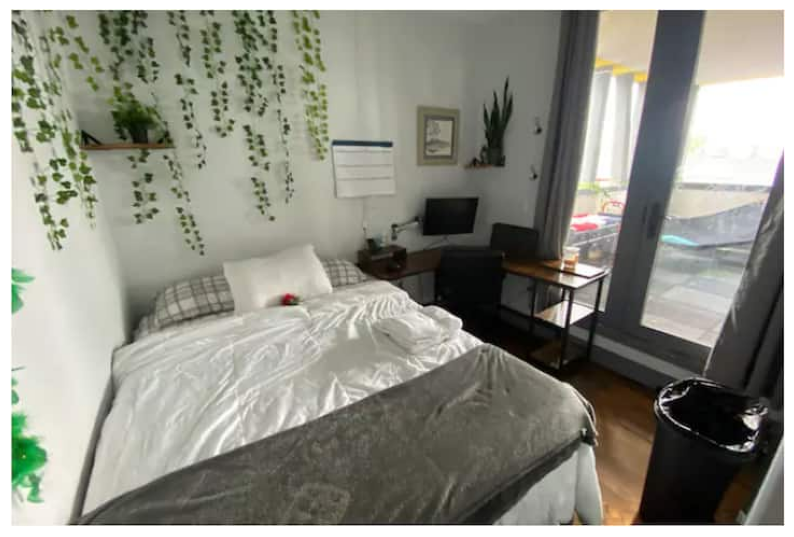

In [9]:
example_row = images_data.iloc[4]
image = bytes_to_image(example_row["image"])
# longest_side = max(image.shape[:2])
# scale = 256 / longest_side
# new_shape = (int(image.shape[1] * scale), int(image.shape[0] * scale))
# image = cv2.resize(image, new_shape, interpolation=cv2.INTER_AREA)
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

Time: 2.88s


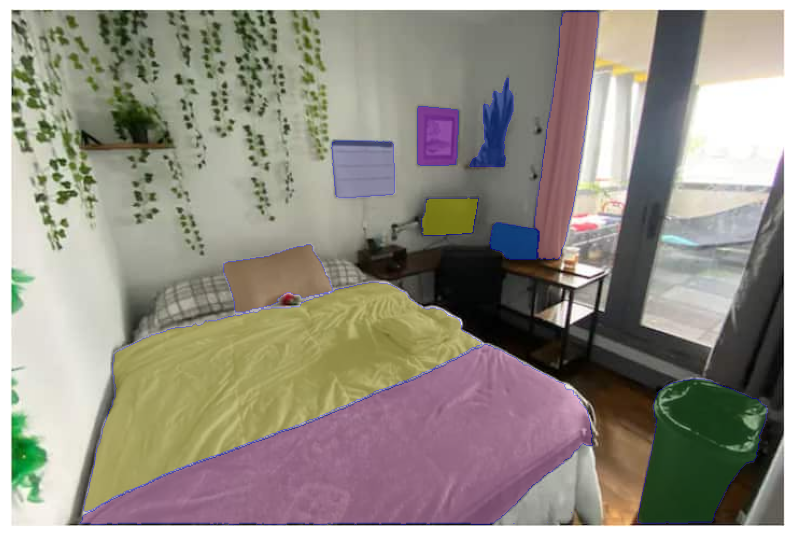

In [10]:
start = time.perf_counter()
masks = mask_generator.generate(image)
print(f"Time: {time.perf_counter() - start:.2f}s")
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

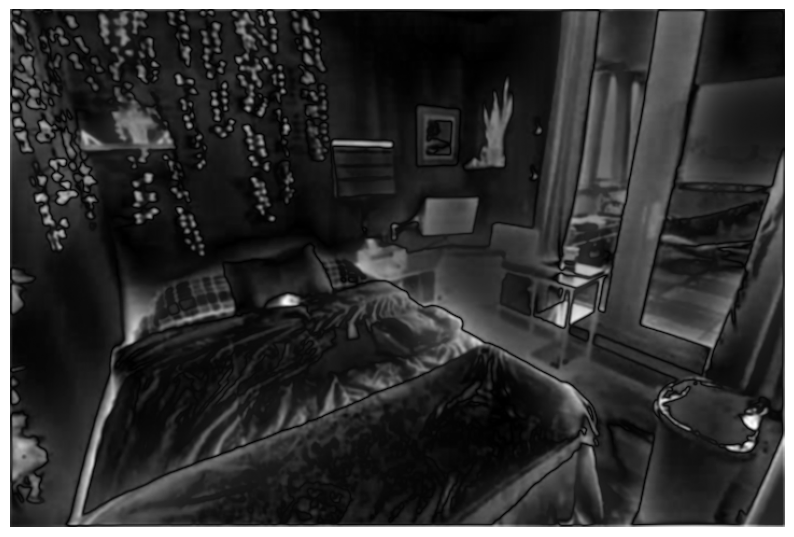

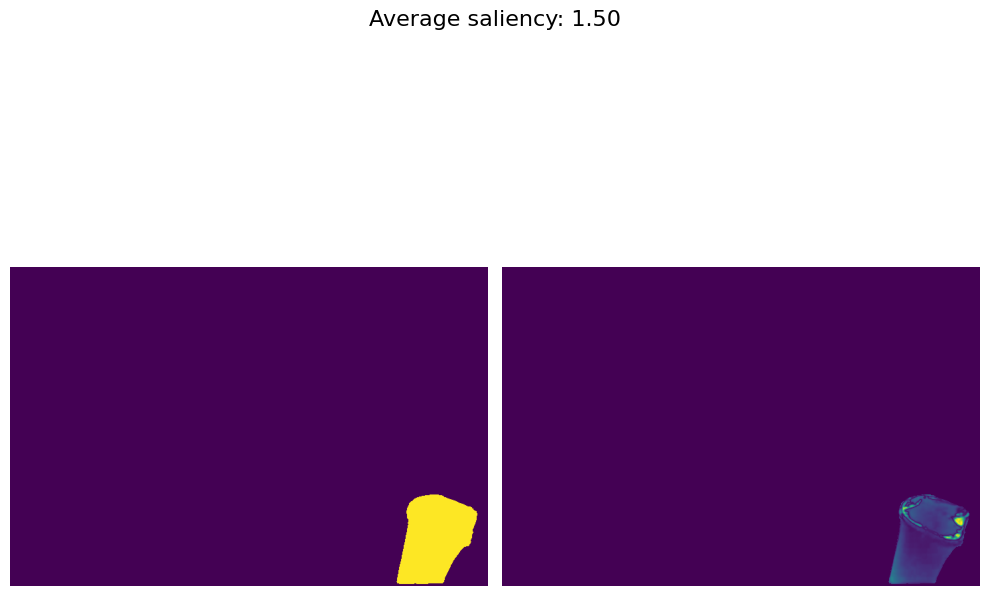

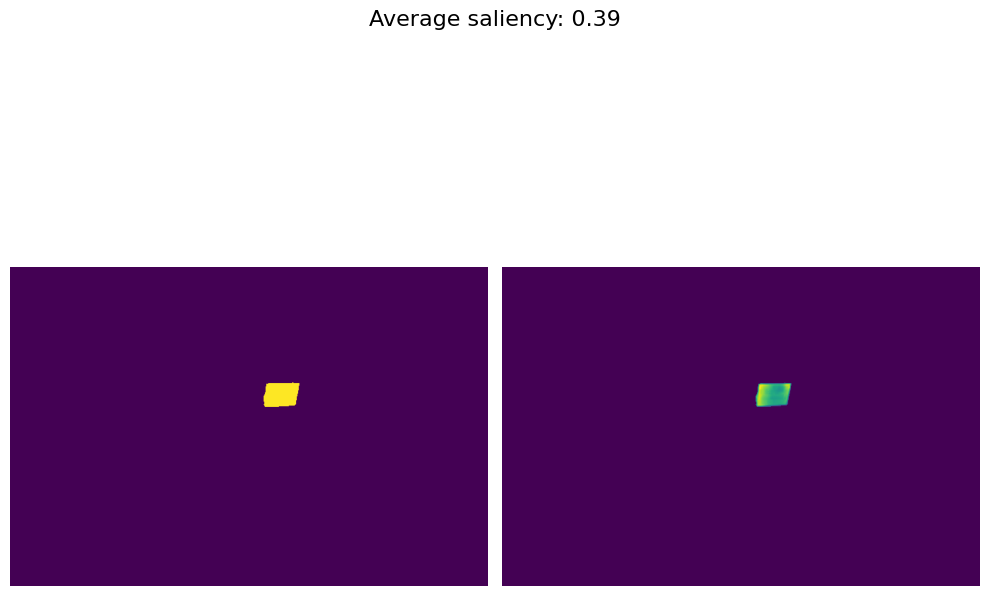

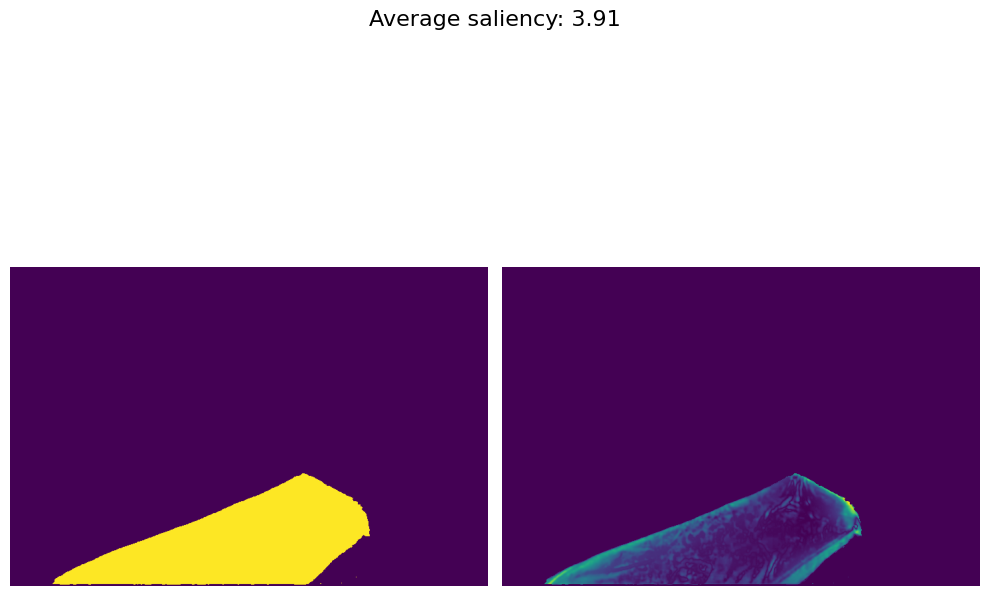

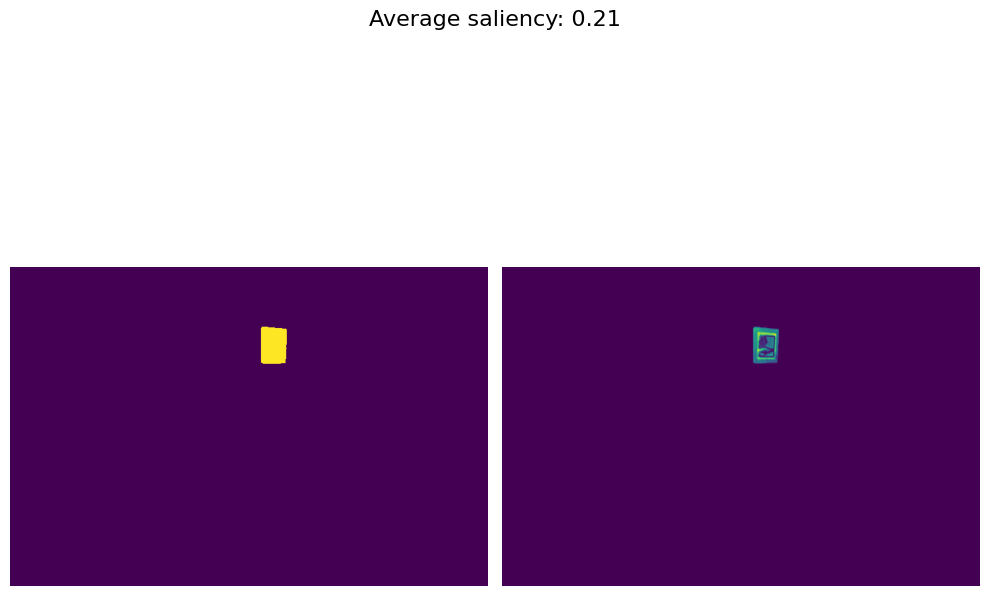

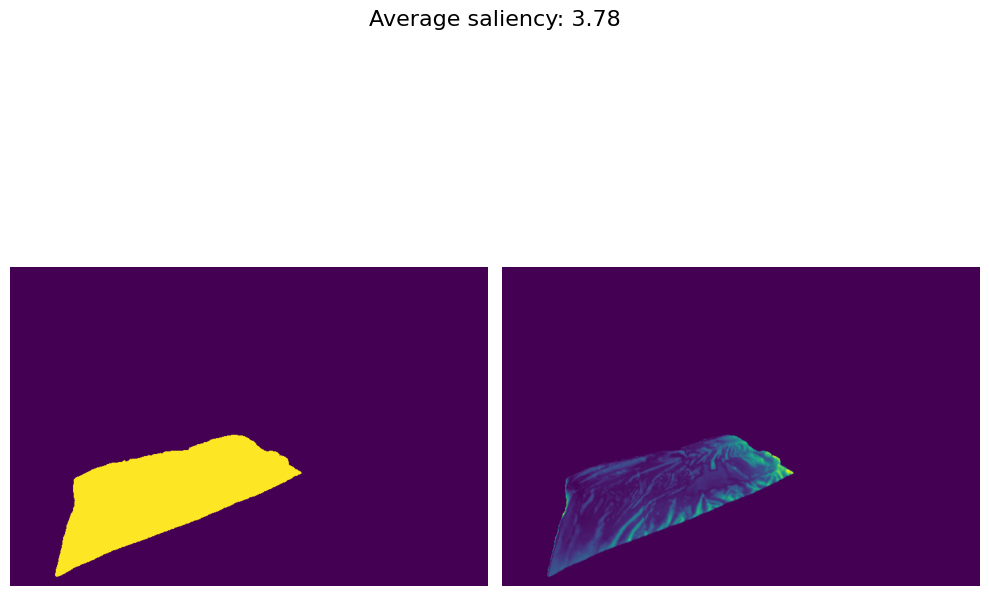

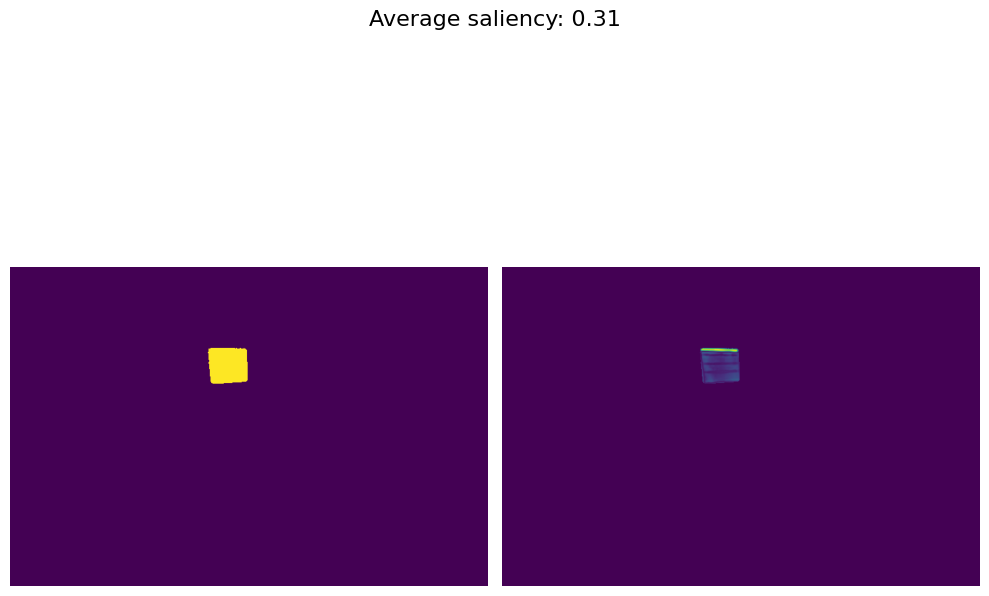

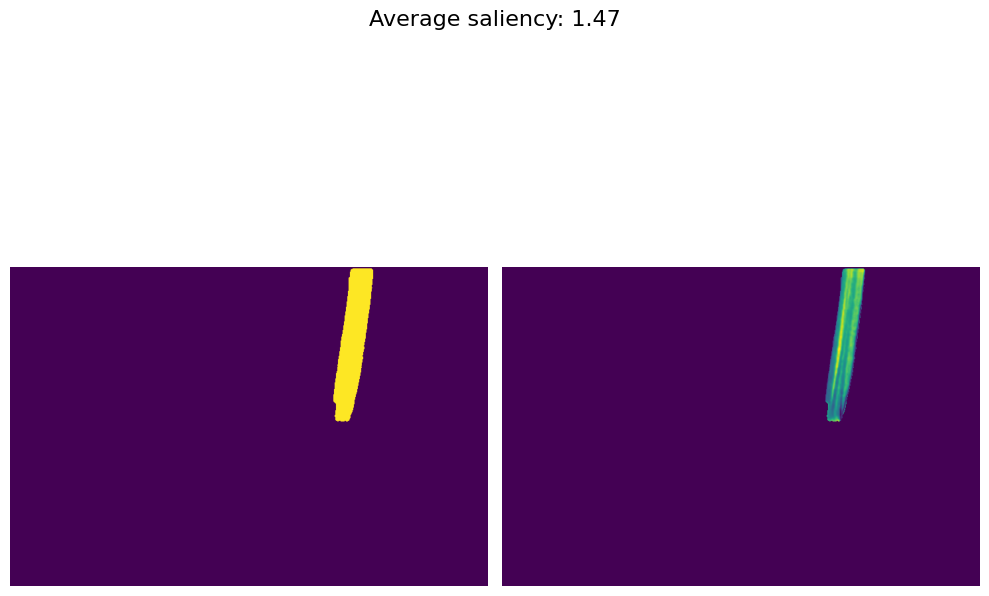

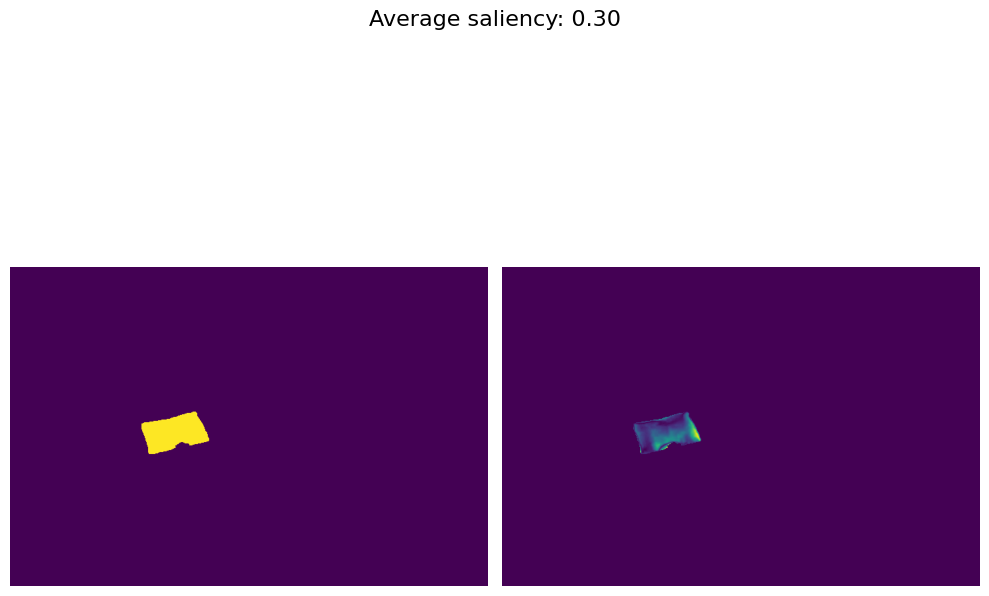

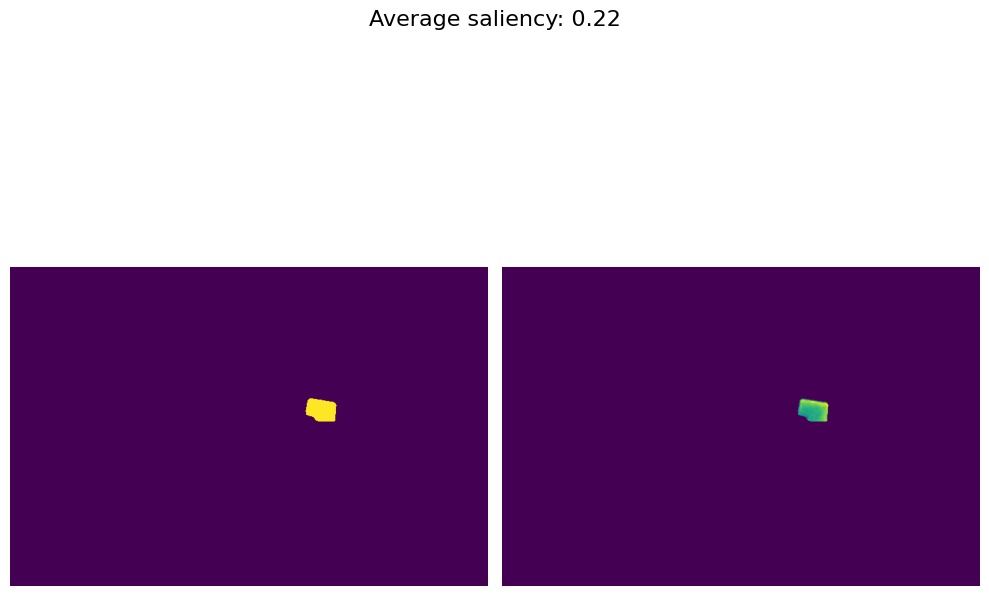

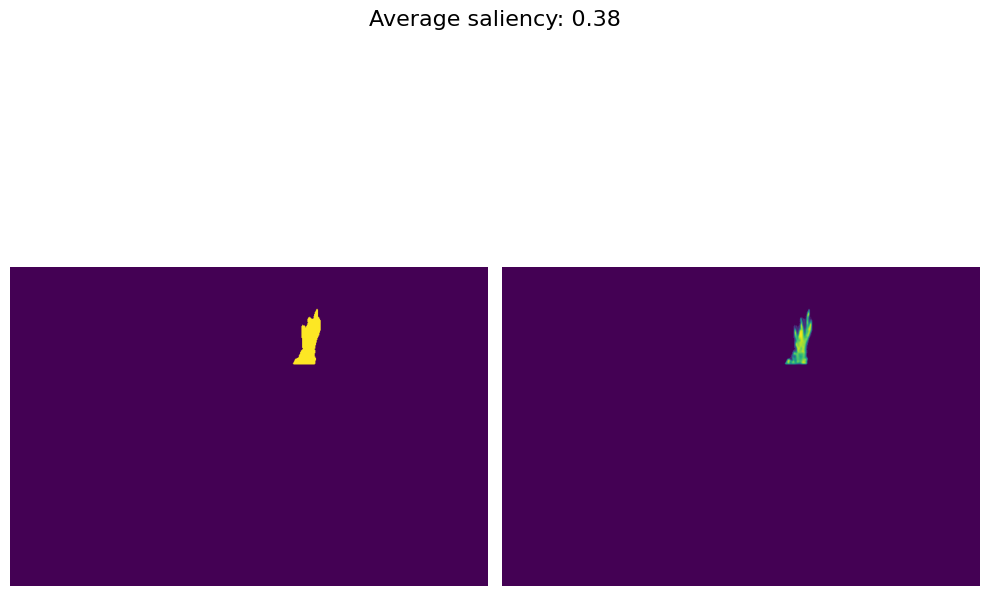

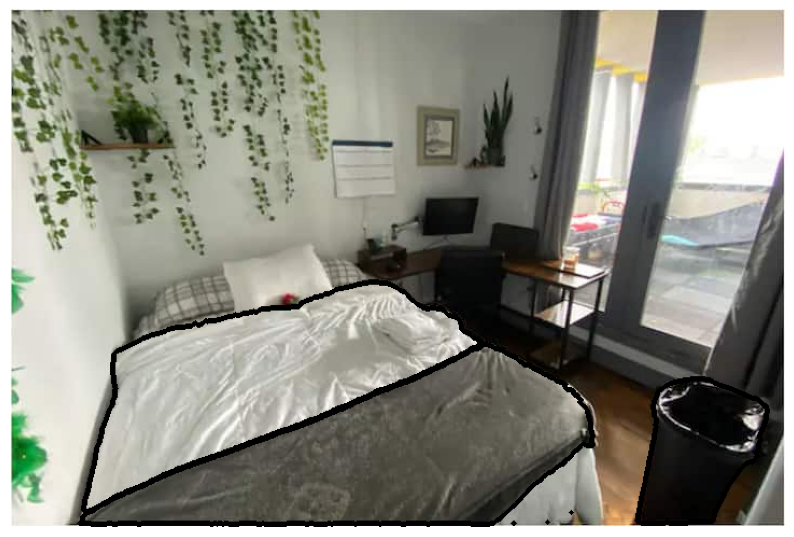

In [11]:
def calculate_average_saliency_map(saliency_map, mask):
    object_Y_coords, object_X_coords = np.where(mask)
    mask = np.zeros_like(saliency_map)
    mask[object_Y_coords, object_X_coords] = 1
    mask_saliency = saliency_map * mask
    avg_saliency = mask_saliency.sum() / mask.sum()
    avg_saliency = mask_saliency.mean()
    return avg_saliency, mask_saliency

def get_saliency_map(rgb_image):
    saliency = cv2.saliency.StaticSaliencyFineGrained_create()
    (success, saliency_map) = saliency.computeSaliency(rgb_image)
    saliency_map = (saliency_map * 255).astype("uint8")
    return saliency_map

def visualize_average_saliency_map(image, masks):
    saliency_map = get_saliency_map(image)
    # saliency_map_threshold = 2*np.mean(saliency_map[saliency_map > 0])
    # saliency_map[saliency_map < saliency_map_threshold] = 0
    plt.figure(figsize=(10, 10))
    plt.imshow(saliency_map, cmap='gray')
    plt.axis('off')
    plt.show()
    masks = [mask['segmentation'] for mask in masks]
    # preprocessed_masks = preprocess_masks(masks)
    for mask in masks:
        avg_saliency, mask_saliency = calculate_average_saliency_map(saliency_map, mask)
        fig, ax = plt.subplots(1, 2, figsize=(10, 10))
        fig.suptitle(f"Average saliency: {avg_saliency:.2f}", fontsize=16, y=0.9)
        ax[0].imshow(mask)
        ax[0].axis('off')
        ax[1].imshow(mask_saliency)
        ax[1].axis('off')
        fig.tight_layout()
        plt.show()

average_saliency_map = visualize_average_saliency_map(image, masks)

def get_top_3_salient_masks(image, masks):
    saliency_map = get_saliency_map(image)
    masks = [mask['segmentation'] for mask in masks]
    # preprocessed_masks = preprocess_masks(masks)
    saliency_scores = []
    for mask in masks:
        avg_saliency, _ = calculate_average_saliency_map(saliency_map, mask)
        saliency_scores.append(avg_saliency)
    top_3_indices = np.argsort(saliency_scores)[-3:][::-1]
    selected_masks = [masks[i] for i in top_3_indices]
    #Now find final saliency_maps which will be a list of top 3 saliency maps (but with values only for the mask rest will be 0)
    final_saliency_maps = []
    for mask in selected_masks:
        object_Y_coords, object_X_coords = np.where(mask)
        mask = np.zeros_like(saliency_map)
        mask[object_Y_coords, object_X_coords] = 1
        mask_saliency = saliency_map * mask
        final_saliency_maps.append(mask_saliency)
    return final_saliency_maps

top_3_masks = get_top_3_salient_masks(image, masks)
def show_masks(image, masks):
    image_copy = image.copy()
    colors = np.random.rand(len(masks), 3)
    for i, mask in enumerate(masks):
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        cv2.drawContours(image_copy, contours, -1, colors[i], thickness=3)
    plt.figure(figsize=(10, 10))
    plt.imshow(image_copy)
    plt.axis('off')
    plt.show()

show_masks(image, top_3_masks)

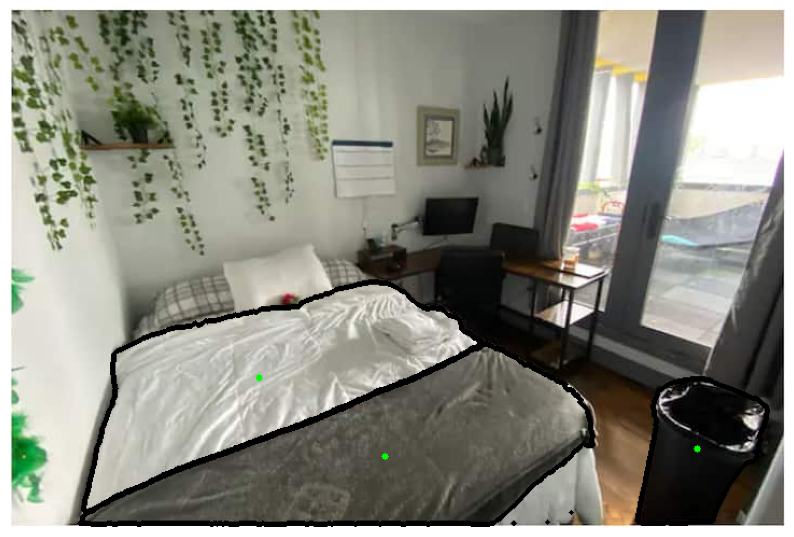

In [12]:
def calculate_centroid(saliency_map):
    object_Y_coords, object_X_coords = np.where(saliency_map)
    centroid = np.array([object_X_coords, object_Y_coords]).T.mean(axis=0)
    return centroid

def show_centroids(image, masks, centroids):
    colors = np.random.rand(len(masks), 3)
    image_copy = image.copy()
    for i, mask in enumerate(masks):
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        cv2.drawContours(image_copy, contours, -1, colors[i], thickness=3)
        cv2.circle(image_copy, (int(centroids[i][0]), int(centroids[i][1])), 3, (0, 255, 0), -1)
    plt.figure(figsize=(10, 10))
    plt.imshow(image_copy)
    plt.axis('off')
    plt.show()

centroids = [calculate_centroid(mask) for mask in top_3_masks]
show_centroids(image, top_3_masks, centroids)

# Image composition

In [13]:
class SalientObjectDetection:
    def __init__(self, mask_segmentation_model: SAM2AutomaticMaskGenerator) -> None:
        """
        Initialize the SalientObjectDetection class.
        
        Args:
            mask_segmentation_model (SAM2AutomaticMaskGenerator): The pretrained model for automatic mask generation.
        """
        self.mask_segmentation_model = mask_segmentation_model
        self.saliency_model = cv2.saliency.StaticSaliencyFineGrained_create()
    
    def detect_salient_objects(self, image: np.ndarray) -> tuple[list[np.ndarray], list[tuple[int]]]:
        """
        Get the top 3 salient objects and their centroids from the input image.
        
        Args:
            image (np.ndarray): The input image.
        
        Returns:
            tuple[list[np.ndarray], list[tuple[int]]]: The top 3 salient masks and their centroids
        """
        masks = self.generate_masks(image)
        saliency_map = self.get_saliency_map(image)
        top_3_masks = self.get_top_3_salient_masks(masks, saliency_map)
        centroids = [self.calculate_centroid(mask) for mask in top_3_masks]
        return top_3_masks, centroids
    
    def generate_masks(self, image: np.ndarray) -> list[np.ndarray]:
        """
        Generate masks for the image.
        
        Args:
            image (np.ndarray): The input image.
        
        Returns:
            list[np.ndarray]: The masks generated for the image.
        """
        masks = self.mask_segmentation_model.generate(image)
        return [mask['segmentation'] for mask in masks]

    def get_saliency_map(self, rgb_image: np.ndarray) -> np.ndarray:
        """
        Get the saliency map for the input image.
        
        Args:
            rgb_image (np.ndarray): The input image.
        
        Returns:
            np.ndarray: The saliency map.
        """
        (_, saliency_map) = self.saliency_model.computeSaliency(rgb_image)
        saliency_map = (saliency_map * 255).astype("uint8")
        return saliency_map
    
    def get_top_3_salient_masks(self, masks: list[np.ndarray], saliency_map: np.ndarray) -> list[np.ndarray]:
        """
        Get the top 3 salient masks from the image.
        
        Args:
            image (np.ndarray): The input image.
            masks (list[np.ndarray]): The masks generated for the image.
            saliency_map (np.ndarray): The saliency map for the input image.
        
        Returns:
            list[np.ndarray]: The top 3 salient masks.
        """
        saliency_scores = [calculate_average_saliency_map(saliency_map, mask)[0] for mask in masks]
        top_3_indices = np.argsort(saliency_scores)[-3:][::-1]
        top_3_masks = [masks[i] for i in top_3_indices]
        top_3_masks = self.draw_masks(top_3_masks, saliency_map)
        return top_3_masks
    
    def draw_masks(self, masks: list[np.ndarray], saliency_map: np.ndarray) -> list[np.ndarray]:
        """
        Draw the masks on the image.
        
        Args:
            masks (list[np.ndarray]): The masks to be drawn on the image.
            saliency_map (np.ndarray): The saliency map for the input image.
        
        Returns:
            np.ndarray: The image with the masks drawn on it.
        """
        saliency_maps = []
        for mask in masks:
            object_Y_coords, object_X_coords = np.where(mask)
            mask = np.zeros_like(saliency_map)
            mask[object_Y_coords, object_X_coords] = 1
            mask_saliency = saliency_map * mask
            saliency_maps.append(mask_saliency)
        return saliency_maps
    
    def calculate_centroid(self, saliency_map: np.ndarray) -> tuple[int]:
        """
        Calculate the centroid of the salient object.
        
        Args:
            saliency_map (np.ndarray): The saliency map for the input image.
        
        Returns:
            tuple[int]: The centroid of the salient object.
        """
        object_Y_coords, object_X_coords = np.where(saliency_map)
        centroid = np.array([object_X_coords, object_Y_coords]).T.mean(axis=0)
        return centroid

salient_object_detection = SalientObjectDetection(mask_generator)
top_3_masks, centroids = salient_object_detection.detect_salient_objects(image)

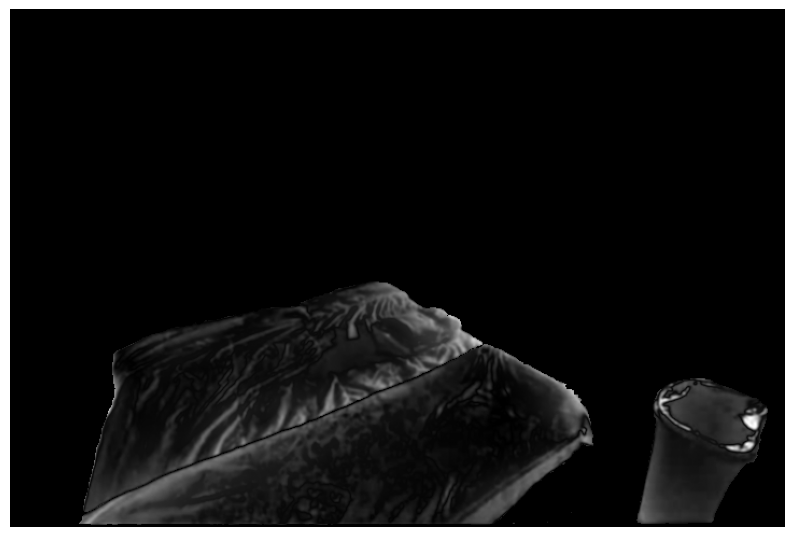

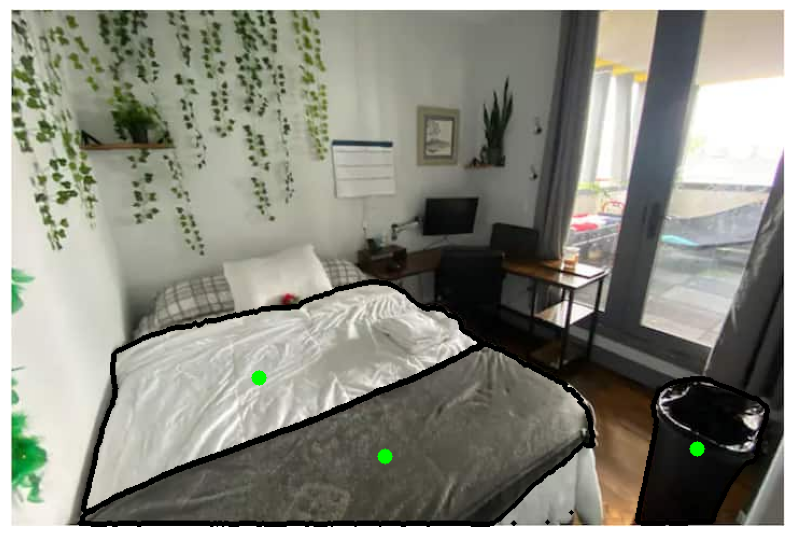

In [14]:
def show_masks(image, masks, centroids):
    mask_plot = np.zeros(image.shape[:2])
    for mask in masks:
        mask_plot += mask
    plt.figure(figsize=(10, 10))
    plt.imshow(mask_plot, cmap='gray')
    plt.axis('off')
    plt.show()
    image_copy = image.copy()
    colors = np.random.rand(len(masks), 3)
    for i, mask in enumerate(masks):
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        cv2.drawContours(image_copy, contours, -1, colors[i], thickness=3)
        cv2.circle(image_copy, (int(centroids[i][0]), int(centroids[i][1])), 7, (0, 255, 0), -1)
    plt.figure(figsize=(10, 10))
    plt.imshow(image_copy)
    plt.axis('off')
    plt.show()

show_masks(image, top_3_masks, centroids)

In [15]:
import math
from itertools import combinations
class ImageComposition:
    def calculate_image_composition_attributes(self, image: np.ndarray, centroids: list[tuple[int]]) -> dict[str, float]:
        """
        Calculate the image composition attributes for the input image.
        
        Args:
            image (np.ndarray): The input image.
            centroids (list[tuple[int]]): The centroids of the salient objects in the image.
        
        Returns:
            dict[str, float]: The image composition attributes.
        """
        if(len(centroids) == 0):
            return {
                'rule_of_thirds': 0,
                'diagonal_dominance': 0,
                'visual_balance': 0
            }
        rule_of_thirds = self.calculate_rule_of_thirds(image, centroids)
        image_composition_attributes = {
            'rule_of_thirds': rule_of_thirds,
        }
        diagonal_dominance = self.calculate_diagonal_dominance(image, centroids)
        visual_balance = self.calculate_visual_balance(image, centroids)
        image_composition_attributes = {
            'rule_of_thirds': rule_of_thirds,
            'diagonal_dominance': diagonal_dominance,
            'visual_balance': visual_balance
        }
        return image_composition_attributes
    
    def calculate_rule_of_thirds(self, image: np.ndarray, centroids: list[tuple[int]]) -> float:
        """
        Calculate the rule of thirds for the input image.
        
        Args:
            image (np.ndarray): The input image.
            centroids (list[tuple[int]]): The centroids of the salient objects in the image.
        
        Returns:
            float: The rule of thirds value.
        """
        height, width = image.shape[:2]
        grid_x = [width // 3, 2 * width // 3]
        grid_y = [height // 3, 2 * height // 3]
        power_points = [(grid_x[0], grid_y[0]), (grid_x[1], grid_y[0]), (grid_x[0], grid_y[1]), (grid_x[1], grid_y[1])]
        rule_of_thirds = []
        for centroid in centroids:
            distances = []
            for power_point in power_points:
                distance = 3*np.linalg.norm(np.array(centroid) - np.array(power_point))/np.sqrt(width**2 + height**2)
                distances.append(distance)
            rule_of_thirds.append(np.min(distances))
        return 1-np.min(rule_of_thirds)
    
    def calculate_diagonal_dominance(self, image: np.ndarray, centroids: list[tuple[int]]) -> float:
        """
        Calculate the diagonal dominance for the input image.
        
        Args:
            image (np.ndarray): The input image.
            centroids (list[tuple[int]]): The centroids of the salient objects in the image.
        
        Returns:
            float: The diagonal dominance value.
        """
        height, width = image.shape[:2]
        diagonal_lines = [(0, 0), (width, height)], [(0, height), (width, 0)]
        diagonal_lines = [np.array(line) for line in diagonal_lines]
        diagonal_distances = []
        if len(centroids) == 1:
            return 0
        centroid_pairs = list(combinations(centroids, 2))
        for centroid_pair in centroid_pairs:
            line = np.array(centroid_pair)
            distances = []
            for diagonal_line in diagonal_lines:
                slope_line = self.calculate_slope(line[0][0], line[0][1], line[1][0], line[1][1])
                slope_diagonal = self.calculate_slope(diagonal_line[0][0], diagonal_line[0][1], diagonal_line[1][0], diagonal_line[1][1])
                angle = self.calculate_angle(slope_line, slope_diagonal)
                d_a = 1-math.cos(math.radians(angle))
                center_point_of_line = line.mean(axis=0)
                d_e = self.calculate_distance_between_point_and_line(image, center_point_of_line, diagonal_line)
                diagonal_distance = 0.5 * (d_a + d_e)
                distances.append(diagonal_distance)
            diagonal_distances.append(np.min(distances))
        return 1-np.min(diagonal_distances)
    
    def calculate_slope(self, x1: int, y1: int, x2: int, y2: int) -> float:
        """
        Calculate the slope of the line.
        
        Args:
            x1 (int): The x-coordinate of the first point.
            y1 (int): The y-coordinate of the first point.
            x2 (int): The x-coordinate of the second point.
            y2 (int): The y-coordinate of the second point.
        
        Returns:
            float: The slope of the line.
        """
        return (y2 - y1) / (x2 - x1)
    
    def calculate_angle(self, slope1: float, slope2: float) -> float:
        """
        Calculate the angle between two slopes.
        
        Args:
            slope1 (float): The first slope.
            slope2 (float): The second slope.
        
        Returns:
            float: The angle between the two slopes.
        """
        return math.degrees(math.atan((slope2-slope1)/(1+(slope2*slope1))))
    
    def calculate_distance_between_point_and_line(self, image, point: np.ndarray, line: np.ndarray) -> float:
        """
        Calculate the distance between a point and a line.
        
        Args:
            image (np.ndarray): The input image.
            point (np.ndarray): The point.
            line (np.ndarray): The line.
        
        Returns:
            float: The distance between the point and the line.
        """
        height, width = image.shape[:2]
        line_point1, line_point2 = line
        distance = np.linalg.norm(np.cross(line_point2 - line_point1, line_point1 - point)) / np.linalg.norm(line_point2 - line_point1)
        normalized_distance = distance / (0.5 * math.sqrt(width**2 + height**2))
        return normalized_distance
    
    def calculate_visual_balance(self, image: np.ndarray, centroids: list[tuple[int]]) -> float:
        """
        Calculate the visual balance for the input image.
        
        Args:
            image (np.ndarray): The input image.
            centroids (list[tuple[int]]): The centroids of the salient objects in the image.
        
        Returns:
            float: The visual balance value.
        """
        height, width = image.shape[:2]
        visual_balance = []
        image_center = np.array([width // 2, height // 2])
        center_of_mass = np.sum(np.array(centroids), axis=0) / len(centroids)
        visual_balance = (2 / np.sqrt(width**2 + height**2) * np.linalg.norm(center_of_mass - image_center))
        return 1-visual_balance

image_composition = ImageComposition()
image_composition_attributes = image_composition.calculate_image_composition_attributes(image, centroids)

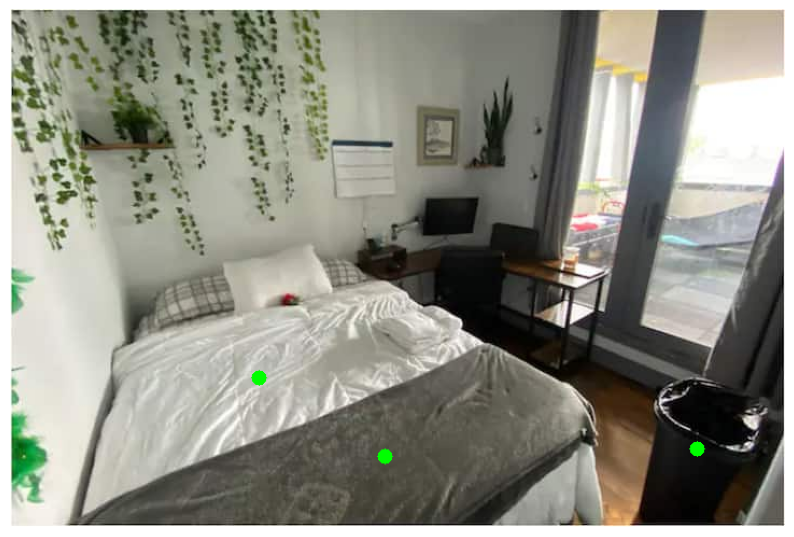

In [16]:
image_with_centroids = image.copy()
for i, centroid in enumerate(centroids):
    cv2.circle(image_with_centroids, (int(centroid[0]), int(centroid[1])), 7, (0, 255, 0), -1)
plt.figure(figsize=(10, 10))
plt.imshow(image_with_centroids)
plt.axis('off')
plt.show()

## Rule of thirds

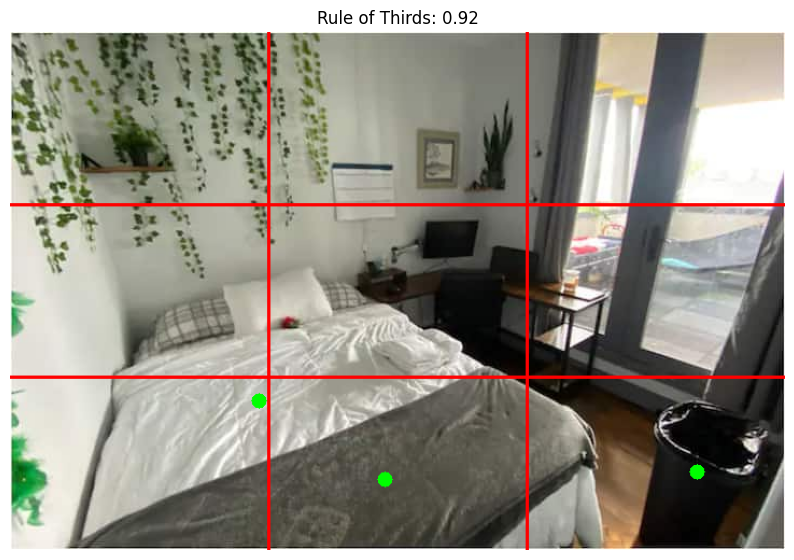

In [17]:
def show_rule_of_thirds(image, centroids, rule_of_thirds_value):
    image_with_centroids = image.copy()
    for i, centroid in enumerate(centroids):
        cv2.circle(image_with_centroids, (int(centroid[0]), int(centroid[1])), 7, (0, 255, 0), -1)
    height, width = image_with_centroids.shape[:2]
    grid_x = [width // 3, 2 * width // 3]
    grid_y = [height // 3, 2 * height // 3]
    for gx in grid_x:
        cv2.line(image_with_centroids, (gx, 0), (gx, height), (255, 0, 0), 2)
    for gy in grid_y:
        cv2.line(image_with_centroids, (0, gy), (width, gy), (255, 0, 0), 2)
    plt.figure(figsize=(10, 10))
    plt.title(f"Rule of Thirds: {rule_of_thirds_value:.2f}")
    plt.imshow(image_with_centroids)
    plt.axis('off')
    plt.show()

#E_3 = min(3*(||centroid - power_point||)/sqrt(width^2 + height^2))
#In rule of thirds power point is the point where two lines intersect
show_rule_of_thirds(image, centroids, image_composition_attributes['rule_of_thirds'])

## Diagonal dominance

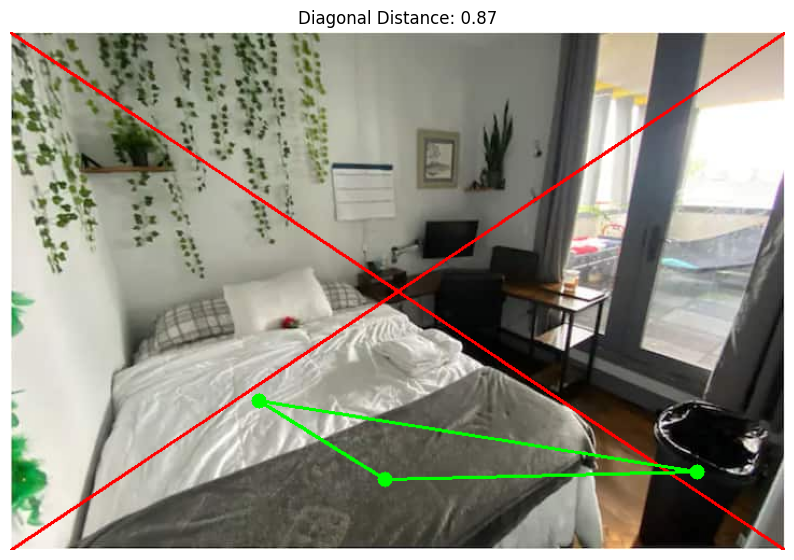

In [18]:
def show_diagonal_dominance(image, centroids, diagonal_dominance_value):
    image_diagonal_dominance = image.copy()
    height, width = image.shape[:2]
    diagonal_lines = [(0, 0), (width, height)], [(0, height), (width, 0)]
    for line in diagonal_lines:
        cv2.line(image_diagonal_dominance, line[0], line[1], (255, 0, 0), 2)
    for centroid in centroids:
        cv2.circle(image_diagonal_dominance, (int(centroid[0]), int(centroid[1])), 7, (0, 255, 0), -1)
    centroid_pairs = list(combinations(centroids, 2))
    for pair in centroid_pairs:
        cv2.line(image_diagonal_dominance, (int(pair[0][0]), int(pair[0][1])), (int(pair[1][0]), int(pair[1][1])), (0, 255, 0), 2)
    plt.figure(figsize=(10, 10))
    plt.title(f"Diagonal Distance: {diagonal_dominance_value:.2f}")
    plt.imshow(image_diagonal_dominance)
    plt.axis('off')
    plt.show()

# E_diag = min(1/2*(d_a(l_mn, L_i))+d_e*(l_mn, L_i))
# L1, L2 - two diagonal lines of the image
# l_mn - line connecting two centroids of objects
# d_a(l_mn, L_i) - cosine of angle between l_mn and L_i
# d_e(l_mn, L_i) - smallest distance between center of l_mn and diagonal L_i normalized by 1/2*sqrt(width^2 + height^2)
show_diagonal_dominance(image, centroids, image_composition_attributes['diagonal_dominance'])

## Visual balance

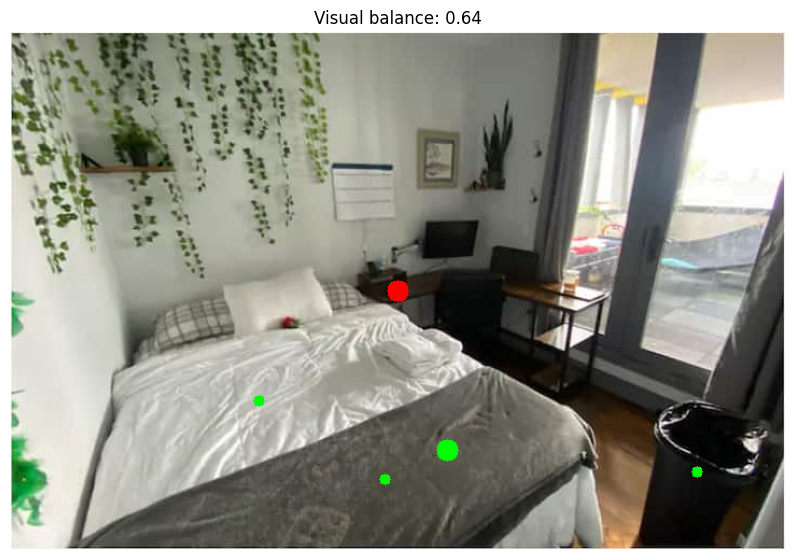

In [19]:
def show_visual_balance(image, centroids, visual_balance_value):
    image_with_center_of_mass = image.copy()
    height, width = image.shape[:2]
    image_center = np.array([width // 2, height // 2])
    center_of_mass = np.sum(np.array(centroids), axis=0) / len(centroids)
    cv2.circle(image_with_center_of_mass, (image_center[0], image_center[1]), 10, (255, 0, 0), -1)
    cv2.circle(image_with_center_of_mass, (int(center_of_mass[0]), int(center_of_mass[1])), 10, (0, 255, 0), -1)
    for i, centroid in enumerate(centroids):
        cv2.circle(image_with_center_of_mass, (int(centroid[0]), int(centroid[1])), 5, (0, 255, 0), -1)
    plt.figure(figsize=(10, 10))
    plt.title(f"Visual balance: {visual_balance_value:.2f}")
    plt.imshow(image_with_center_of_mass)
    plt.axis('off')
    plt.show()

# E_vis_bal = (2/(sqrt(width^2 + height^2)))*sum(||center_of_mass - image_center||^2)^(1/3)
show_visual_balance(image, centroids, image_composition_attributes['visual_balance'])

# Whole dataset

In [ ]:
from tqdm import tqdm
insert_script = "INSERT INTO images_composition_attributes (id, rule_of_thirds, diagonal_dominance, visual_balance) VALUES (%s, %s, %s, %s)"
with tqdm(
        total=len(images_data),
        unit="images",
        unit_scale=True,
        desc=f"Processing images",
    ) as pbar:
    for index, row in images_data.iterrows():
        if row['id'] in images_composition_attributes_data_ids:
            pbar.update(1)
            continue
        bytes_image = row["image"]
        if not bytes_image:
            pbar.update(1)
            values = (row['id'], 0, 0, 0)
            cursor.execute(insert_script, values)
            DB.commit()
            continue
        image = bytes_to_image(row['image'])
        top_3_masks, centroids = salient_object_detection.detect_salient_objects(image)
        image_composition_attributes = image_composition.calculate_image_composition_attributes(image, centroids)
        for attribute, value in image_composition_attributes.items():
            images_data.at[index, attribute] = value
        values = (row['id'], float(image_composition_attributes['rule_of_thirds']), float(image_composition_attributes['diagonal_dominance']), float(image_composition_attributes['visual_balance']))
        cursor.execute(insert_script, values)
        DB.commit()
        pbar.update(1)

Processing images:  40%|███▉      | 146k/369k [43:03:54<161:59:30, 2.61s/images] 